In [1]:
# All Imports

import numpy as np
import os
import re
import torch
import torchvision.transforms as T
import torchvision.models as models
import rasterio
from rasterio.plot import reshape_as_image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from skimage.transform import resize
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import geopandas as gpd

from sklearn.metrics import (
    classification_report, 
    accuracy_score, 
    f1_score,
    confusion_matrix
)

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

import xgboost as xgb

from sklearn.decomposition import IncrementalPCA
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import euclidean_distances

import shap

from mpl_toolkits.mplot3d import Axes3D

from hmmlearn.hmm import GaussianHMM
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from PIL import Image

from rasterio import open as rio_open
from rasterio.mask import mask
from skimage.filters import sobel

from sklearn.preprocessing import StandardScaler
from skimage.feature import corner_harris, corner_peaks, graycomatrix, graycoprops
from scipy.stats import entropy as scipy_entropy
from skimage.measure import label, regionprops

from prophet import Prophet
from prophet.plot import plot_cross_validation_metric
from prophet.diagnostics import cross_validation, performance_metrics

from itertools import product

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from typing import Union

Importing plotly failed. Interactive plots will not work.


# Data Import

In [2]:
# path to space-net data
BASE_DIR = "C:\\Users\\zizzi\\MATH 7339\\Final Project\\archive (4)\\SN7_buildings_train\\train"

def extract_season_from_filename(filename):

    # use filename to get season it was take in, e.g. 201803 -> spring

    month = int(filename[20:22])
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    elif month in [9, 10, 11]:
        return "fall"


def extract_year_month(fname):
    match = re.search(r"(\d{4})_(\d{2})", fname)
    if not match:
        return none
    year = int(match.group(1))
    month = int(match.group(2))
    return f"{year}{month:02d}"


X = [] # input (all RGB flattedne)

X_reds = [] # individual color bands
X_greens = []
X_blues = []

y = []  # season labels

aoi_labels = [] # area name labels
timestamps = [] # month timestamps
building_counts = [] # # buildings in photo
embeddings = []
processed_files = 0
skipped_files = 0
aoi_count = 0


# res-net18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = torch.nn.Identity()  # replace classifier → output = embedding
resnet = resnet.to(device)
resnet.eval()

# image transform: resize to 224, normalize like ImageNet
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])



# get all AOI directories in the train folder
aoi_dirs = [d for d in os.listdir(BASE_DIR) 
            if os.path.isdir(os.path.join(BASE_DIR, d))]


for aoi_dir in aoi_dirs:
    aoi_count += 1
    img_dir = os.path.join(BASE_DIR, aoi_dir, "images")
    lbl_dir = os.path.join(BASE_DIR, aoi_dir, "labels")

    building_counts_aoi = {}
    
    print(f"Processing AOI {aoi_count}/{len(aoi_dirs)}: {aoi_dir}")

    # labels loop
    for lbl_fname in os.listdir(lbl_dir):
        if not lbl_fname.endswith("Buildings.geojson"):
            continue
        
        timestamp = extract_year_month(lbl_fname)
        if timestamp is None:
            continue
        
        path = os.path.join(lbl_dir, lbl_fname)
        gdf = gpd.read_file(path)

        building_counts_aoi[timestamp] = len(gdf)

    print("retrieved building counts for ", aoi_dir)
    building_counts.append(building_counts_aoi)
        
    # images loop
    for fname in os.listdir(img_dir):
        if not fname.endswith(".tif"):
            continue
        
        season = extract_season_from_filename(fname)
        if season is None:
            skipped_files += 1
            continue
        
        img_path = os.path.join(img_dir, fname)
        
        try:

            # RGB array data
            with rasterio.open(img_path) as src:
                img = src.read()  # bands, H, W
            
            img = reshape_as_image(img) # H, W bands
            
            # check if image has enough bands
            if img.shape[2] < 3:
                print(f"Warning: Image {fname} has only {img.shape[2]} bands, skipping")
                skipped_files += 1
                continue
            
            # the images are 4-band (RGB + NIR), take RGB only (no NIR is this case, all =255)
            rgb = img[:, :, :3]
            
            # got away with resizing to 256 without analysis change
            rgb_small = resize(rgb, (256, 256), anti_aliasing=True)
            
            # flatten image to 1D feature vector
            feature_vec = rgb_small.flatten()

            # indiv rgbs
            red_vec = np.mean(rgb_small[:, :, 0])
            green_vec = np.mean(rgb_small[:, :, 1])
            blues_vec = np.mean(rgb_small[:, :, 2])

            
            # res-net18 embeddings
            img = Image.open(img_path).convert("RGB")
            x = transform(img).unsqueeze(0).to(device)
            with torch.no_grad():
                emb = resnet(x).cpu().numpy().squeeze()
            

            timestamp = extract_year_month(fname)
            aoi_label = fname[34:50]
            
            X.append(feature_vec)
            X_greens.append(green_vec)
            X_reds.append(red_vec)
            X_blues.append(blues_vec)
            embeddings.append(emb)
            
            y.append(season)
            aoi_labels.append(aoi_label)
            timestamps.append(timestamp)
            processed_files += 1
            
            # Progress update
            if processed_files % 100 == 0:
                print(f"  Processed {processed_files} images")

        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            skipped_files += 1
            continue

X = np.array(X)
X_reds = np.array(X_reds)
X_greens = np.array(X_greens)
X_blues = np.array(X_blues)
embeddings = np.array(embeddings)
y = np.array(y)
aoi_labels = np.array(aoi_labels)

print(f"\nSummary:")
print(f"  Processed {processed_files} images from {aoi_count} AOI directories")
print(f"  Season Counts: {np.unique(y, return_counts=True)}")

Processing AOI 1/60: L15-0331E-1257N_1327_3160_13
retrieved building counts for  L15-0331E-1257N_1327_3160_13
Processing AOI 2/60: L15-0357E-1223N_1429_3296_13
retrieved building counts for  L15-0357E-1223N_1429_3296_13
Processing AOI 3/60: L15-0358E-1220N_1433_3310_13
retrieved building counts for  L15-0358E-1220N_1433_3310_13
Processing AOI 4/60: L15-0361E-1300N_1446_2989_13
retrieved building counts for  L15-0361E-1300N_1446_2989_13
Processing AOI 5/60: L15-0368E-1245N_1474_3210_13
retrieved building counts for  L15-0368E-1245N_1474_3210_13
  Processed 100 images
Processing AOI 6/60: L15-0387E-1276N_1549_3087_13
retrieved building counts for  L15-0387E-1276N_1549_3087_13
Processing AOI 7/60: L15-0434E-1218N_1736_3318_13
retrieved building counts for  L15-0434E-1218N_1736_3318_13
Processing AOI 8/60: L15-0457E-1135N_1831_3648_13
retrieved building counts for  L15-0457E-1135N_1831_3648_13
Processing AOI 9/60: L15-0487E-1246N_1950_3207_13
retrieved building counts for  L15-0487E-1246N_

KeyboardInterrupt: 

#### Incremental PCA

In [ ]:
# using incremental pca to reduce huge 256*256*3 image array size, might not be full necessary compared to just using PCA() but want to try this

def apply_incremental_pca(X, n_components=100, batch_size=1000):

    ipca = IncrementalPCA(n_components=n_components, batch_size=batch_size)
    
    # batches
    n_samples = len(X)
    for i in range(0, n_samples, batch_size):
        batch = X[i:min(i + batch_size, n_samples)]
        ipca.partial_fit(batch)
        print(f"Processed {min(i + batch_size, n_samples)}/{n_samples} samples")

    # apply pca to that bach
    X_transformed = np.zeros((n_samples, n_components))
    for i in range(0, n_samples, batch_size):
        batch = X[i:min(i + batch_size, n_samples)]
        X_transformed[i:i+len(batch)] = ipca.transform(batch)
    
    explained_variance = np.sum(ipca.explained_variance_ratio_)
    print("Explained variance:" , explained_variance)
    
    return X_transformed

X_pca = apply_incremental_pca(X, n_components=200, batch_size=500)

In [ ]:
pca = PCA(n_components=0.9)
emb_2d = pca.fit_transform(embeddings)

print("PCA explained variance:", pca.explained_variance_ratio_)

In [ ]:
# using PCA reduced rbg X as main input data, have the option of using emb_2d as well
X = X_pca

# Supervised Season Classifiers

## All models

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:" , len(X_train))
print("Test set size:" , len(X_test))

In [ ]:
# Random Forest
clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest classifier...")
clf.fit(X_train, y_train)

print("\nMaking predictions...")
pred_rf = clf.predict(X_test)

accuracy_rf = accuracy_score(y_test, pred_rf)
f1_rf = f1_score(y_test, pred_rf, average='weighted')

print("\nSeason Classification Report:\n")
print(classification_report(y_test, pred_rf))


In [ ]:
# Bagging 
from sklearn.ensemble import BaggingClassifier

# create bagging ensemble
bagged_lr = BaggingClassifier(
    estimator=clf,
    n_estimators=50, # 50 is usually my default,, will play around with 
    max_samples=0.8,  # fraction of samples to draw for each model, typically play around with 0.5-0.8
    max_features=0.8,  # fraction of features to draw for each model
    random_state=42,
    n_jobs=-1
)

print("\nTraining Bagged RF classifier...")
bagged_lr.fit(X_train, y_train)

print("\nMaking predictions...")
pred_bag = bagged_lr.predict(X_test)

accuracy_bag = accuracy_score(y_test, pred_bag)
f1_bag = f1_score(y_test, pred_bag, average='weighted')

print("\nSeason Classification Report:\n")
print(classification_report(y_test, pred_bag))

In [ ]:
# SVM

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        random_state=42,
        probability=True
    ))
])

print("\nTraining SVM classifier...")
svm_pipeline.fit(X_train, y_train)

print("\nMaking predictions...")
pred_svm = svm_pipeline.predict(X_test)

accuracy_svm = accuracy_score(y_test, pred_svm)
f1_svm = f1_score(y_test, pred_svm, average='weighted')

print("\nSeason Classification Report:\n")
print(classification_report(y_test, pred_svm))

In [ ]:
# Naive Bayes

nb_clf = GaussianNB()

print("\nTraining Naives Bayes classifier...")
nb_clf.fit(X_train, y_train)

print("\nMaking predictions...")
pred_nb = nb_clf.predict(X_test)

accuracy_nb = accuracy_score(y_test, pred_nb)
f1_nb = f1_score(y_test, pred_nb, average='weighted')

print("\nSeason Classification Report:\n")
print(classification_report(y_test, pred_nb))

In [ ]:
# KNN

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        algorithm='auto',
        n_jobs=-1,
        metric='minkowski',
        p=2
    ))
])

print("\nTraining KNN classifier...")
knn_pipeline.fit(X_train, y_train)

print("\nMaking predictions...")
pred_knn = knn_pipeline.predict(X_test)

accuracy_knn = accuracy_score(y_test, pred_knn)
f1_knn = f1_score(y_test, pred_knn, average='weighted')

print("\nSeason Classification Report:\n")
print(classification_report(y_test, pred_knn))

In [ ]:
# LDA RF

lda_rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

print("\nTraining LDA RF classifier...")
lda_rf_pipeline.fit(X_train, y_train)

print("\nMaking predictions...")
pred_lda_rf = lda_rf_pipeline.predict(X_test)

accuracy_lda_rf = accuracy_score(y_test, pred_lda_rf)
f1_lda_rf = f1_score(y_test, pred_lda_rf, average='weighted')

print("\nSeason Classification Report:\n")
print(classification_report(y_test, pred_lda_rf))

In [ ]:
# XGBoost

y_train_num = y_train.copy()
y_train_num[y_train_num == 'fall'] = 0
y_train_num[y_train_num == 'winter'] = 1
y_train_num[y_train_num == 'spring'] = 2
y_train_num[y_train_num == 'summer'] = 3
y_train_num = y_train_num.astype(int)

y_test_num = y_test[:].copy()
y_test_num[y_test_num == 'fall'] = 0
y_test_num[y_test_num == 'winter'] = 1
y_test_num[y_test_num == 'spring'] = 2
y_test_num[y_test_num == 'summer'] = 3
y_test_num = y_test_num.astype(int)

xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_clf.fit(X_train, y_train_num)

print("\nMaking predictions...")
pred_xgb = xgb_clf.predict(X_test)

accuracy_xgb = accuracy_score(y_test_num, pred_xgb)
f1_xgb = f1_score(y_test_num, pred_xgb, average='weighted')

print("\nSeason Classification Report:\n")
print(classification_report(y_test_num, pred_xgb))

In [ ]:
results = [{'Classifier': "Random Forest",
                'Accuracy': accuracy_rf,
                'F1 Score': f1_rf
           },
           {'Classifier': "Bagged RF",
               'Accuracy': accuracy_bag,
                'F1 Score': f1_bag
           },
           
          {'Classifier': "SVM",
                'Accuracy': accuracy_svm,
                'F1 Score': f1_svm
            },
          {'Classifier': "Naive Bayes",
                'Accuracy': accuracy_nb,
                'F1 Score': f1_nb
            },
          {'Classifier': "KNN",
                'Accuracy': accuracy_knn,
                'F1 Score': f1_knn
            },
          {'Classifier': "LDA RF",
                'Accuracy': accuracy_lda_rf,
                'F1 Score': f1_lda_rf
            },
          {'Classifier': "XGBoost",
                'Accuracy': accuracy_xgb,
                'F1 Score': f1_xgb
            }]

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))

## Spread of accuracies per AOI

In [ ]:
aoi_accuracies = {}
invalid_aois = []

# cycle through aoi folder and generate classifier model with only that area's data
for aoi in aoi_dirs:
    
    aoi = aoi[4:20]
    print("Testing AOI:", aoi)

    X_aoi = []
    y_aoi = []

    aoi_indices = np.where(aoi_labels == aoi)
    
    for i in range(len(aoi_labels[aoi_labels == aoi])):
        X_aoi.append(X[aoi_indices[0][i]])
        y_aoi.append(y[aoi_indices[0][i]])


    X_aoi = np.array(X_aoi)
    y_aoi = np.array(y_aoi)

    if min(np.unique(y_aoi, return_counts=True)[1]) > 2:

        X_train, X_test, y_train, y_test = train_test_split(X_aoi, y_aoi, test_size=0.2, random_state=42, stratify=y_aoi)

        clf = RandomForestClassifier(
            n_estimators=150,
            max_depth=20,
            random_state=42
        )
    
        clf.fit(X_train, y_train)
        pred_aoi = clf.predict(X_test)
    
        acc = accuracy_score(y_test, pred_aoi)
        aoi_accuracies[aoi] = acc

    else: 
        invalid_aois.append(aoi)

invalid_aois = np.array(invalid_aois)
aoi_acc_df = pd.DataFrame(list(aoi_accuracies.items()), columns=["AOI", "Accuracy"])
print(aoi_acc_df.sort_values("Accuracy", ascending=False))

In [ ]:
X_greens

### Look at distribution of RGB values per season for commonalities

In [ ]:
df_season_bands = pd.DataFrame({"Means": np.mean(X, axis=1)})
df_season_bands["Greens"] = X_greens
df_season_bands["Reds"] = X_reds
df_season_bands["Blues"] = X_blues
df_season_bands['Season'] = y
df_season_bands

In [ ]:
for season in df_season_bands['Season'].unique():
    if pd.notna(season):
        bands_data = df_season_bands[df_season_bands['Season'] == season]['Means'].dropna()
        plt.hist(bands_data, alpha=0.6, label=season, bins=35)
plt.title("Histogram of Mean PCA Values (All Bands) By Season")
plt.legend()

In [ ]:
for season in df_season_bands['Season'].unique():
    if pd.notna(season):
        bands_data = df_season_bands[df_season_bands['Season'] == season]['Greens'].dropna()
        plt.hist(bands_data, alpha=0.6, label=season, bins=55)
plt.title("Histogram of Mean Green Values By Season")
plt.legend()

In [ ]:
for season in df_season_bands['Season'].unique():
    if pd.notna(season):
        bands_data = df_season_bands[df_season_bands['Season'] == season]['Reds'].dropna()
        plt.hist(bands_data, alpha=0.6, label=season, bins=35)
plt.title("Histogram of Mean Red Values By Season")
plt.legend()

In [ ]:
for season in df_season_bands['Season'].unique():
    if pd.notna(season):
        species_data = df_season_bands[df_season_bands['Season'] == season]['Blues'].dropna()
        plt.hist(species_data, alpha=0.6, label=season, bins=35)
plt.title("Histogram of Mean Blue Values By Season")
plt.legend()

In [ ]:
np.unique(aoi_labels)
for aoi_id in np.unique(aoi_labels):
    print(aoi_id)

## "Seasonality" Classifier (data = per AOI metrics, y = AOI accuracy for season)

In [ ]:
def seasonal_contrasts(X_area, y_area):
    out = {}
    seasons = ["winter", "spring", "summer", "fall"]
    centroids = {}

    for s in seasons:
        centroids[s] = X_area[np.array(y_area) == s].mean(axis=0)

    for s1 in seasons:
        for s2 in seasons:
            if s1 < s2:
                dist = np.linalg.norm(centroids[s1] - centroids[s2])
                out[f"{s1}_{s2}_dist"] = dist

    return out


aoi_features_rgb = []
aoi_features_emb = []

for aoi_id in np.unique(aoi_labels):

    if aoi_id not in invalid_aois:

        aoi_indices = list(np.where(aoi_labels == aoi_id))[0]


        # rgb features
        X_area = X[min(aoi_indices):max(aoi_indices)+1]  # e.g shape (24, 200)
        X_green = X_greens[min(aoi_indices):max(aoi_indices)+1]

        feature_dict_rgb = {}

        # PCA dim-wise stats
        feature_dict_rgb.update({
            f"pca_mean_{i}": X_area[:, i].mean()
            for i in range(200)
        })
        feature_dict_rgb.update({
            f"pca_std_{i}": X_area[:, i].std()
            for i in range(200)
        })
        feature_dict_rgb.update({
            f"pca_range_{i}": np.ptp(X_area[:, i])
            for i in range(200)
        })

        # Season constrasts
        seasonal_contrasts_dict = seasonal_contrasts(X_area, y[min(aoi_indices):max(aoi_indices)+1])
    
        for i in range(6):
            pairing = list(seasonal_contrasts_dict.keys())[i]
            value = list(seasonal_contrasts_dict.values())[i]
            feature_dict_rgb[pairing] = value

        # Total seasonal variation
        feature_dict_rgb["total_variation"] = X_area.var(axis=0).sum()
        feature_dict_rgb["green_variation"] = X_green.var(axis=0).sum()

        aoi_features_rgb.append(feature_dict_rgb)


        # resnet features
        X_area = emb_2d[min(aoi_indices):max(aoi_indices)+1]
        X_green = X_greens[min(aoi_indices):max(aoi_indices)+1]

        feature_dict_emb = {}
        
        feature_dict_emb.update({
            f"pca_mean_{i}": X_area[:, i].mean()
            for i in range(75)
        })
        feature_dict_emb.update({
            f"pca_std_{i}": X_area[:, i].std()
            for i in range(75)
        })
        feature_dict_emb.update({
            f"pca_range_{i}": np.ptp(X_area[:, i])
            for i in range(75)
        })

        # Season constrasts
        seasonal_contrasts_dict = seasonal_contrasts(X_area, y[min(aoi_indices):max(aoi_indices)+1])
    
        for i in range(6):
            pairing = list(seasonal_contrasts_dict.keys())[i]
            value = list(seasonal_contrasts_dict.values())[i]
            feature_dict_emb[pairing] = value

        # Total seasonal variation
        feature_dict_emb["total_variation"] = X_area.var(axis=0).sum()
        feature_dict_emb["green_variation"] = X_green.var(axis=0).sum()

        aoi_features_emb.append(feature_dict_emb)
        
        

aoi_features_rgb = pd.DataFrame(aoi_features_rgb)
aoi_features_emb = pd.DataFrame(aoi_features_emb)

In [ ]:
aoi_features_rgb.head(5)

In [ ]:
aoi_features_emb.head(5)

In [ ]:
accuracies = np.array(aoi_acc_df["Accuracy"])
accuracies

In [ ]:
y_aoi

In [ ]:
from sklearn import metrics
X_train, X_test, y_train, y_test = train_test_split(
    aoi_features_rgb, accuracies, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=1000, random_state=42)
rf.fit(X_train, y_train)

predictions = rf.predict(X_test)
errors = abs((predictions - y_test)/y_test)
print('Mean Relative Error:', round(np.mean(errors), 2)) 
print('R^2:', metrics.r2_score(y_test, predictions))

importances = pd.Series(rf.feature_importances_, index=aoi_features_rgb.columns)
important = importances.sort_values(ascending=False).head(20)
print(important)


In [ ]:
explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(aoi_features_rgb)

shap.summary_plot(shap_vals, aoi_features_rgb, show=False)
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches='tight')

In [ ]:
from sklearn import metrics
X_train, X_test, y_train, y_test = train_test_split(
    aoi_features_emb, accuracies, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=1000, random_state=42)
rf.fit(X_train, y_train)

predictions = rf.predict(X_test)
errors = abs((predictions - y_test)/y_test)
print('Mean Relative Error:', round(np.mean(errors), 2)) 
print('R^2:', metrics.r2_score(y_test, predictions))

importances = pd.Series(rf.feature_importances_, index=aoi_features_emb.columns)
important = importances.sort_values(ascending=False).head(20)
print(important)


# Latent Season Modeling

In [ ]:
# for just modeling 2 states: if an area "has seasonality" or follows the seasonal trends I set up
K = 2  # number of latent seasonal states

hmm = GaussianHMM(
    n_components=K,
    covariance_type="full",
    n_iter=200,
    random_state=0
)

In [ ]:
hmm.fit(X)
latent_states = hmm.predict(X)
latent_states

In [ ]:
pca2 = PCA(n_components=3) # reduction jsut for visualization
features_2d = pca2.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

custom_labels = ["State 1", "State 2"]

for k in range(2):
    cluster_pts = features_2d[latent_states == k]
    ax.scatter(cluster_pts[:,0], cluster_pts[:,1], cluster_pts[:,2],
               label=custom_labels[k], alpha=0.6, s=40)


ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("GMM With 2 Seasonality States")
ax.legend()
plt.show()

In [36]:
silhouette_score(X, latent_states)

0.22770419165562664

In [37]:
davies_bouldin_score(X, latent_states)

1.5586382342572045

In [38]:
calinski_harabasz_score(X, latent_states)

513.6124367927558

### Isolate 4 season modeling to AOI known to "look seasonal"

In [39]:
contra_costa = "0331E-1257N_1327"
cc_indices = list(np.where(aoi_labels == contra_costa))[0]
X_cc = X[min(cc_indices):max(cc_indices)+1]

In [40]:
X_cc.shape

(25, 200)

In [41]:
K = 4

hmm = GaussianHMM(
    n_components=K,
    covariance_type="full",
    n_iter=200,
    random_state=0
)

hmm.fit(X_cc)
latent_states = hmm.predict(X_cc)

Fitting a model with 81215 free scalar parameters with only 5000 data points will result in a degenerate solution.
C:\Users\zizzi\anaconda3\envs\geo\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


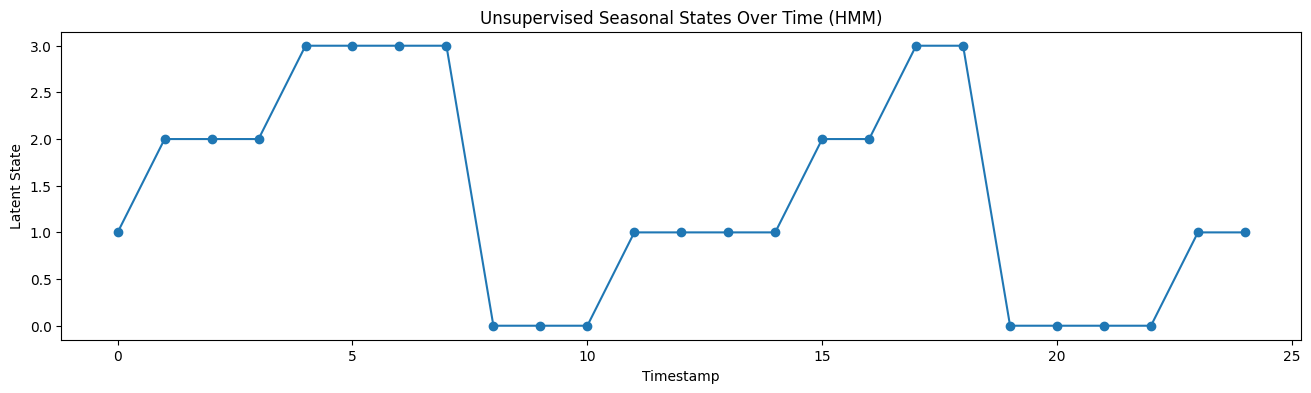

In [42]:
plt.figure(figsize=(16, 4))
plt.plot(np.argsort(timestamps[min(cc_indices):max(cc_indices)+1]), latent_states, marker='o', linestyle='-')
plt.title("Unsupervised Seasonal States Over Time (HMM)")
plt.xlabel("Timestamp")
plt.ylabel("Latent State")
plt.show()

NOTE: due to small change in data preprocessing, this chart looks different from the one on the paper, but that is simply due to difference in the assignment of the state numbers, and cyclic HMM states are still visible.

# Unsupervised Urban Sectors Masking of Area 0487E-1246N_1950

## Basic Gaussian - Pixel Intensity Threshold

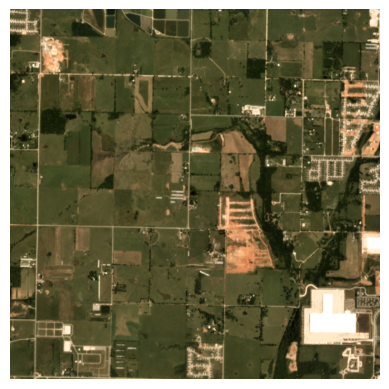

In [43]:
tif_path = 'C:\\Users\\zizzi\\MATH 7339\\Final Project\\archive (4)\\SN7_buildings_train\\train\\L15-0487E-1246N_1950_3207_13\\images_masked\\global_monthly_2019_06_mosaic_L15-0487E-1246N_1950_3207_13.tif'
img = Image.open(tif_path)
plt.imshow(img)
plt.axis('off')  # Optional: hides the axes for a cleaner view
plt.show()

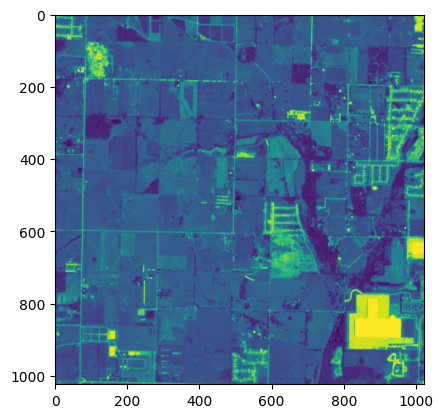

In [44]:
gray = img.convert("L")
gray = np.array(gray)
plt.imshow(gray)

In [45]:
pixels = gray.flatten().reshape(-1, 1)
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=1)
gmm.fit(pixels)

# compute threshold as mean of the two Gaussian means
threshold = np.mean(gmm.means_)

In [46]:
binary_img = (gray > threshold).astype(float)

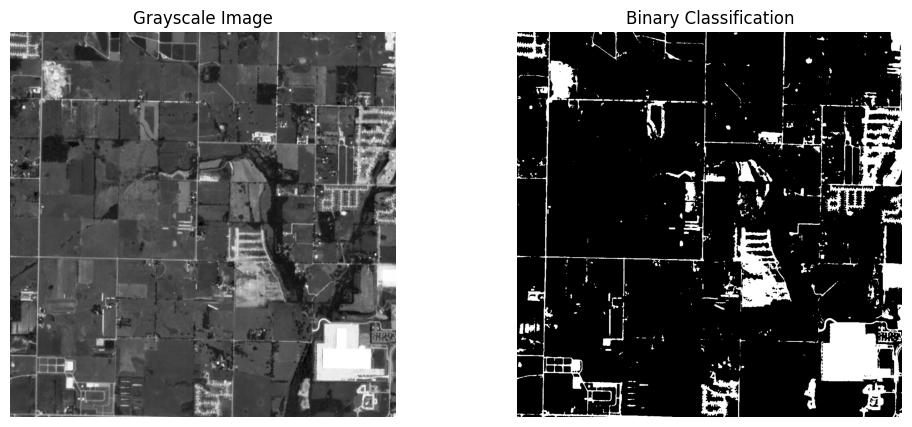

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(binary_img, cmap='gray')
plt.title('Binary Classification')
plt.axis('off')

plt.show()


In [48]:
# gmm1_ss = silhouette_score(pixels, binary_img.flatten())
# gmm1_db = davies_bouldin_score(pixels, binary_img.flatten())
# gmm1_ch = calinski_harabasz_score(pixels, binary_img.flatten())

### Patchwide K=2 GMM, Manmade vs not manmade

Image shape: (1024, 1024, 4)
Feature array shape: (7396, 9)


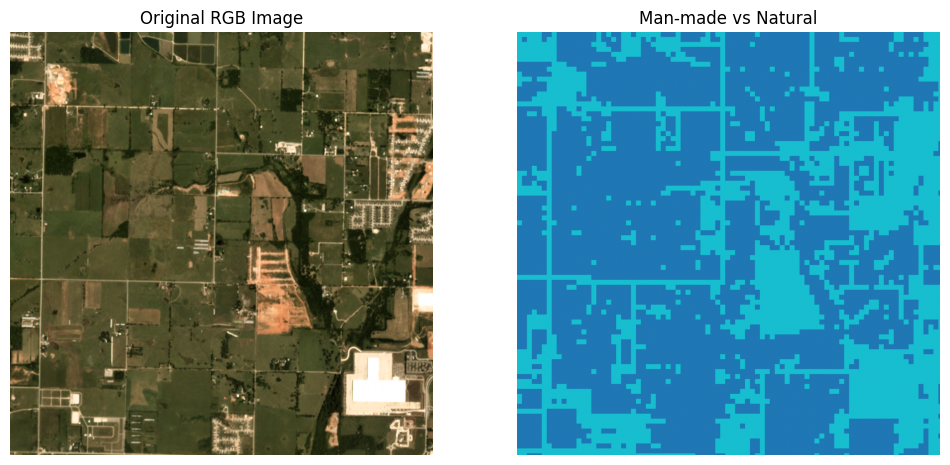

In [50]:
# fresh reread of just area 0487E-1246N_1950 in june 2019
with rio_open(tif_path) as src:
    img = src.read()  # shape: (bands, height, width)
    transform = src.transform
    crs = src.crs

img_array = np.moveaxis(img, 0, -1)  # shape: (H, W, bands)
H, W, B = img_array.shape
print("Image shape:", img_array.shape)

patch_size = 12
features = []
patch_coords = []

for i in range(0, H, patch_size):
    for j in range(0, W, patch_size):
        patch = img_array[i:i+patch_size, j:j+patch_size, :]
        
        # spectral features, mean and std per band
        mean_vals = patch.reshape(-1, B).mean(axis=0)
        std_vals = patch.reshape(-1, B).std(axis=0)
        
        # texture features, edge density using sobel
        # convert to grayscale for edge detection
        grayscale = patch[:, :, :3].mean(axis=2)
        edges = sobel(grayscale)
        edge_density = edges.mean()
        
        feat_vec = np.concatenate([mean_vals, std_vals, [edge_density]])
        features.append(feat_vec)
        patch_coords.append((i, j))

features = np.array(features)
print("Feature array shape:", features.shape)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

gmm = GaussianMixture(n_components=2, random_state=1)
gmm.fit(features_scaled)
labels = gmm.predict(features_scaled)

# map labels back to image
segmented = np.zeros((H, W), dtype=np.uint8)

for idx, (i, j) in enumerate(patch_coords):
    segmented[i:i+patch_size, j:j+patch_size] = labels[idx]

if features[:, -1].mean() > 0.1 and labels.mean() < 1:
    segmented = 1 - segmented


plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.imshow(img_array[:, :, :3].astype(np.uint8))
plt.title("Original RGB Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(segmented, cmap='tab10')
plt.title("Man-made vs Natural")
plt.axis('off')
plt.show()

In [51]:
gmm2_ss = silhouette_score(features_scaled, labels)
gmm2_db = davies_bouldin_score(features_scaled, labels)
gmm2_ch = calinski_harabasz_score(features_scaled, labels)

### Patchwise K=3 GMM, Not manmade vs high density vs low density

#### First attempt

Feature array shape: (16384, 11)


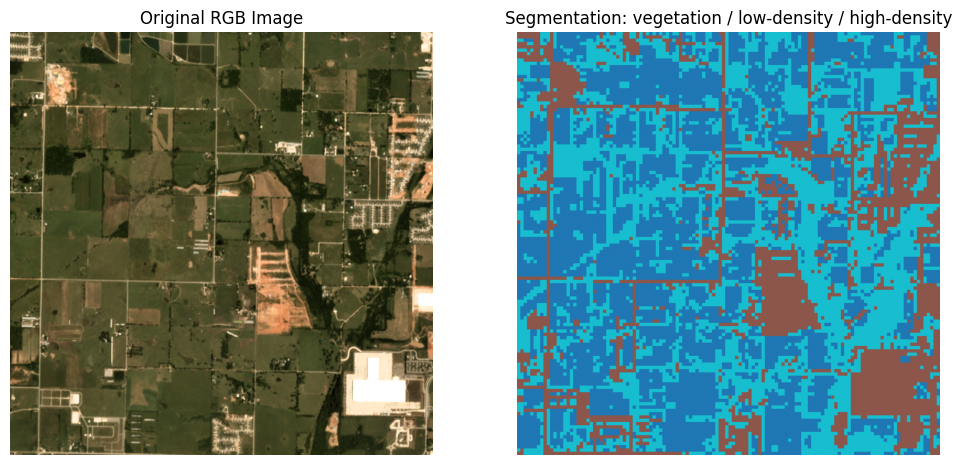

In [53]:

patch_size = 8
features = []
patch_coords = []

def compute_glcm_features(gray_patch, distances=[1], angles=[0]):
    """Compute GLCM contrast and homogeneity for a patch"""
    gray_patch = (gray_patch / gray_patch.max() * 255).astype(np.uint8)
    glcm = graycomatrix(gray_patch, distances=distances, angles=angles, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    return contrast, homogeneity

for i in range(0, H, patch_size):
    for j in range(0, W, patch_size):
        patch = img_array[i:i+patch_size, j:j+patch_size, :]
        
        if patch.shape[0] < patch_size or patch.shape[1] < patch_size:
            continue  # skip incomplete edge patches
        
        # spectral
        mean_vals = patch.reshape(-1, B).mean(axis=0)
        std_vals = patch.reshape(-1, B).std(axis=0)
        
        # new: brightness and greenness
        brightness = mean_vals[:3].mean()
        greenness = mean_vals[1] - mean_vals[0]  # G - R proxy
        
        # texture
        grayscale = patch[:, :, :3].mean(axis=2)
        edge_density = sobel(grayscale).mean()
        
        # GLCM
        contrast, homogeneity = compute_glcm_features(grayscale)
        
        # feature vector
        feat_vec = np.concatenate([mean_vals[:3], std_vals[:3], [brightness, greenness, edge_density, contrast, homogeneity]])
        features.append(feat_vec)
        patch_coords.append((i, j))

features = np.array(features)
print("Feature array shape:", features.shape)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

gmm = GaussianMixture(n_components=3, random_state=1)
gmm.fit(features_scaled)
labels = gmm.predict(features_scaled)

segmented = np.zeros((H, W), dtype=np.uint8)

for idx, (i, j) in enumerate(patch_coords):
    segmented[i:i+patch_size, j:j+patch_size] = labels[idx]

plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.imshow(img_array[:, :, :3].astype(np.uint8))
plt.title("Original RGB Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(segmented, cmap='tab10')
plt.title("Segmentation: vegetation / low-density / high-density")
plt.axis('off')

plt.show()


In [54]:
gmm3_ss = silhouette_score(features_scaled, labels)
gmm3_db = davies_bouldin_score(features_scaled, labels)
gmm3_ch = calinski_harabasz_score(features_scaled, labels)

#### Second attempt

Feature array shape: (16384, 15)


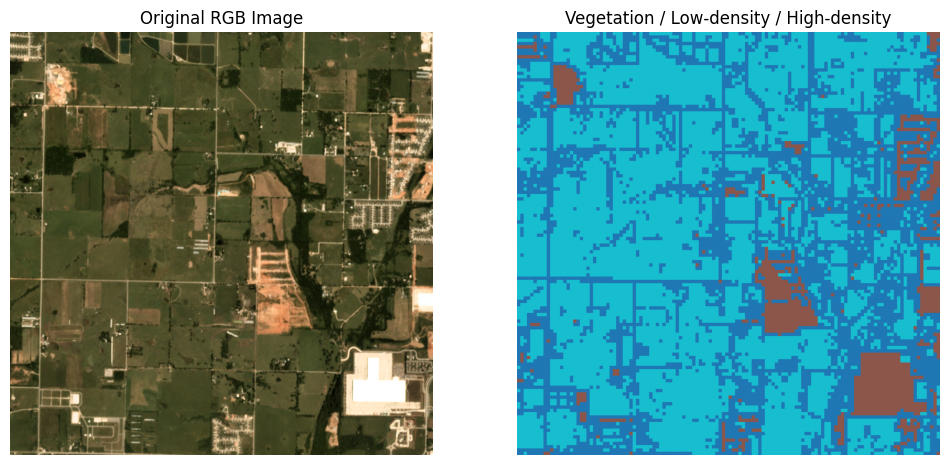

In [55]:

patch_size = 8
features = []
patch_coords = []

# separating some calcs into functions for neatness
def compute_glcm_features(gray_patch, distances=[1], angles=[0]):
    gray_patch = (gray_patch / max(gray_patch.max(), 1e-5) * 255).astype(np.uint8)
    glcm = graycomatrix(gray_patch, distances=distances, angles=angles, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    return contrast, correlation

def compute_patch_entropy(gray_patch, bins=16):
    hist, _ = np.histogram(gray_patch.flatten(), bins=bins, range=(0, 255), density=True)
    hist = hist + 1e-10  # avoid log(0)
    return scipy_entropy(hist)

for i in range(0, H, patch_size):
    for j in range(0, W, patch_size):
        patch = img_array[i:i+patch_size, j:j+patch_size, :]
        if patch.shape[0] < patch_size or patch.shape[1] < patch_size:
            continue
        
        # spectral
        mean_vals = patch.reshape(-1, B).mean(axis=0)
        std_vals = patch.reshape(-1, B).std(axis=0)
        brightness = mean_vals[:3].mean()
        greenness = mean_vals[1] - mean_vals[0]
        
        # texture
        gray = patch[:, :, :3].mean(axis=2)
        edge_density = sobel(gray).mean()
        
        # corner density
        corners = corner_peaks(corner_harris(gray), min_distance=1)
        corner_density = len(corners) / (patch_size * patch_size)
        
        # connected components
        thresh = gray.mean() + gray.std()
        binary = gray > thresh
        labeled = label(binary)
        regions = regionprops(labeled)
        num_components = len(regions)
        avg_area = np.mean([r.area for r in regions]) if regions else 0
        
        # GLCM
        glcm_contrast, glcm_corr = compute_glcm_features(gray)

        patch_entropy = compute_patch_entropy(gray)
        
        # feature vector
        feat_vec = np.concatenate([
            mean_vals[:3], std_vals[:3],
            [brightness, greenness, edge_density, corner_density, num_components, avg_area, glcm_contrast, glcm_corr, patch_entropy]
        ])
        
        features.append(feat_vec)
        patch_coords.append((i, j))

features = np.array(features)
print("Feature array shape:", features.shape)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

gmm = GaussianMixture(n_components=3, random_state=1)
gmm.fit(features_scaled)
labels = gmm.predict(features_scaled)

segmented = np.zeros((H, W), dtype=np.uint8)
for idx, (i, j) in enumerate(patch_coords):
    segmented[i:i+patch_size, j:j+patch_size] = labels[idx]

plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.imshow(img_array[:, :, :3].astype(np.uint8))
plt.title("Original RGB Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(segmented, cmap='tab10')
plt.title("Vegetation / Low-density / High-density")
plt.axis('off')

plt.show()


In [56]:
gmm4_ss = silhouette_score(features_scaled, labels)
gmm4_db = davies_bouldin_score(features_scaled, labels)
gmm4_ch = calinski_harabasz_score(features_scaled, labels)

In [57]:
masking_metrics = [{"GMM #" : 2, "Silhouette Score": gmm2_ss, "Davies Bouldin Score": gmm2_db, "Calinski Harabasz Score": gmm2_ch},
                   {"GMM #" : 3, "Silhouette Score": gmm3_ss, "Davies Bouldin Score": gmm3_db, "Calinski Harabasz Score": gmm3_ch},
                   {"GMM #" : 4, "Silhouette Score": gmm4_ss, "Davies Bouldin Score": gmm4_db, "Calinski Harabasz Score": gmm4_ch}]


masking_metrics_df = pd.DataFrame(masking_metrics)
print(masking_metrics_df)

   GMM #  Silhouette Score  Davies Bouldin Score  Calinski Harabasz Score
0      2          0.497218              0.911633              6224.754162
1      3          0.235813              1.317310              6955.778384
2      4          0.290023              1.349883              5605.140169


# Other topics

## Building count regression

In [58]:
building_counts

[{'201801': 1940,
  '201802': 1960,
  '201803': 1956,
  '201804': 1944,
  '201805': 1966,
  '201806': 1983,
  '201807': 1989,
  '201808': 1991,
  '201809': 1999,
  '201810': 2004,
  '201811': 2004,
  '201812': 2017,
  '201901': 2018,
  '201902': 2019,
  '201903': 2020,
  '201904': 2030,
  '201905': 2029,
  '201906': 2038,
  '201907': 2049,
  '201908': 2043,
  '201909': 2072,
  '201910': 2080,
  '201911': 2089,
  '201912': 2104,
  '202001': 2108},
 {'201801': 4634,
  '201802': 4633,
  '201803': 4650,
  '201804': 4664,
  '201805': 4698,
  '201806': 4739,
  '201807': 4736,
  '201808': 4775,
  '201809': 4791,
  '201810': 4818,
  '201811': 4819,
  '201812': 4819,
  '201901': 4829,
  '201902': 4830,
  '201903': 4830,
  '201904': 4855,
  '201905': 4852,
  '201906': 4858,
  '201907': 4863,
  '201908': 4885,
  '201909': 4890,
  '201910': 4899,
  '201911': 4909,
  '201912': 4908,
  '202001': 4910},
 {'201802': 3970,
  '201803': 3987,
  '201804': 4027,
  '201805': 3798,
  '201806': 4067,
  '20180

In [59]:
building_counts_flat = []
for dict in building_counts:
    for count in dict.values():
        building_counts_flat.append(count)

building_counts_flat = np.array(building_counts_flat)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, building_counts_flat, test_size=0.25, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("\nModel Performance:")
print("MAE (Mean Absolute Error):", mean_absolute_error(y_test, pred))
print("R² Score:", r2_score(y_test, pred))


Model Performance:
MAE (Mean Absolute Error): 521.5479166647051
R² Score: 0.9301156517771895


Text(0, 0.5, 'Predicted Building Counts')

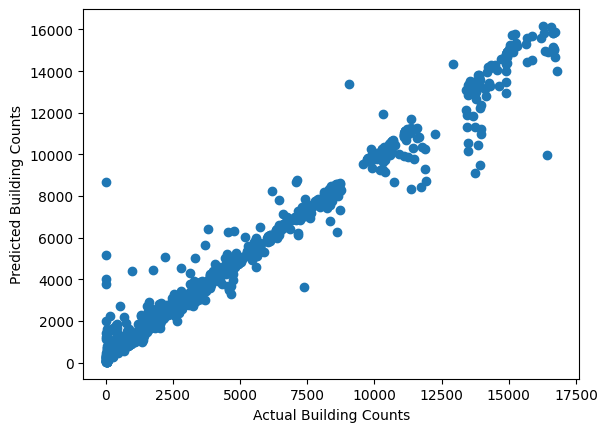

In [61]:
plt.scatter(building_counts_flat, model.predict(X))
plt.xlabel("Actual Building Counts")
plt.ylabel("Predicted Building Counts")

## Time Series ARIMA/SARIMA

The following code is from the TS5_Prophet code from lab 4. I could not find the proper citation.

### ARIMA

In [62]:
aoi_accuracies

{'0331E-1257N_1327': 0.8,
 '0357E-1223N_1429': 0.8,
 '0358E-1220N_1433': 0.6,
 '0361E-1300N_1446': 0.6,
 '0368E-1245N_1474': 0.6,
 '0387E-1276N_1549': 1.0,
 '0434E-1218N_1736': 0.6,
 '0457E-1135N_1831': 0.4,
 '0487E-1246N_1950': 1.0,
 '0506E-1204N_2027': 0.8,
 '0544E-1228N_2176': 0.2,
 '0566E-1185N_2265': 0.8,
 '0571E-1075N_2287': 0.5,
 '0577E-1243N_2309': 0.8,
 '0586E-1127N_2345': 0.6,
 '0595E-1278N_2383': 1.0,
 '0614E-0946N_2459': 0.6,
 '0632E-0892N_2528': 0.6,
 '0683E-1006N_2732': 0.6,
 '0760E-0887N_3041': 1.0,
 '0924E-1108N_3699': 0.8,
 '0977E-1187N_3911': 0.4,
 '1014E-1375N_4056': 0.8,
 '1025E-1366N_4102': 0.6,
 '1049E-1370N_4196': 0.6,
 '1138E-1216N_4553': 0.8,
 '1172E-1306N_4688': 0.8,
 '1185E-0935N_4742': 0.4,
 '1200E-0847N_4802': 0.8,
 '1203E-1203N_4815': 0.5,
 '1204E-1202N_4816': 0.16666666666666666,
 '1204E-1204N_4819': 0.8,
 '1209E-1113N_4838': 1.0,
 '1210E-1025N_4840': 0.4,
 '1276E-1107N_5105': 1.0,
 '1289E-1169N_5156': 0.6,
 '1296E-1198N_5184': 0.8,
 '1298E-1322N_5193': 0

In [63]:
top_15_accuracies = sorted(aoi_accuracies.items(), key=lambda item: item[1], reverse=True)[:15]

# Extract only the keys from the sorted list of tuples
top_15_aois = [item[0] for item in top_15_accuracies]

In [64]:
top_15_aois

['0387E-1276N_1549',
 '0487E-1246N_1950',
 '0595E-1278N_2383',
 '0760E-0887N_3041',
 '1209E-1113N_4838',
 '1276E-1107N_5105',
 '1617E-1207N_6468',
 '1703E-1219N_6813',
 '1848E-0793N_7394',
 '0331E-1257N_1327',
 '0357E-1223N_1429',
 '0506E-1204N_2027',
 '0566E-1185N_2265',
 '0577E-1243N_2309',
 '0924E-1108N_3699']

In [65]:
boolean_mask = np.isin(aoi_labels, top_15_aois)
indices_tuple = np.where(boolean_mask)
indices_seasons = indices_tuple[0]

X_seasons = X_greens[indices_seasons]
timestamps_seasons = np.array(timestamps)[indices_seasons]

In [66]:
def clear_year(s, index, new_char):
    return s[:index] + new_char + s[-2:]
    
pos_to_replace = 0
replacement_char = '2000'
cleared_years = [clear_year(item, pos_to_replace, replacement_char) for item in timestamps_seasons]

timestamps_stacked = []
i = 0
year = 2000
for month in cleared_years:

    if i == 12:
        year += 1
        i=0

    replacement_char = str(year)
    month = clear_year(month, pos_to_replace, replacement_char)
    month = pd.to_datetime(month, format='%Y%m')
    timestamps_stacked.append(month)

    i += 1

ds = np.array(timestamps_stacked)

In [67]:
df = pd.DataFrame({'y': X_seasons, 'ds': ds}, columns=['y', 'ds'])

In [68]:
df

,y,ds
0,0.289978,2000-01-01
1,0.368054,2000-02-01
2,0.380592,2000-03-01
3,0.369503,2000-04-01
4,0.461369,2000-05-01
...,...,...
354,0.254293,2029-09-01
355,0.296573,2029-10-01
356,0.339782,2029-11-01
357,0.348519,2029-12-01


In [69]:
df_prophet = df.copy()
df_prophet = df_prophet.drop_duplicates(subset=["ds"])
df_prophet = df_prophet.sort_values("ds")
df_prophet = df_prophet.reset_index(drop=True)

In [70]:
df_prophet.iloc[274]

y                0.350012
ds    2024-01-01 00:00:00
Name: 274, dtype: object

In [71]:
train = df_prophet.iloc[0:274]
test = df_prophet.iloc[274:]

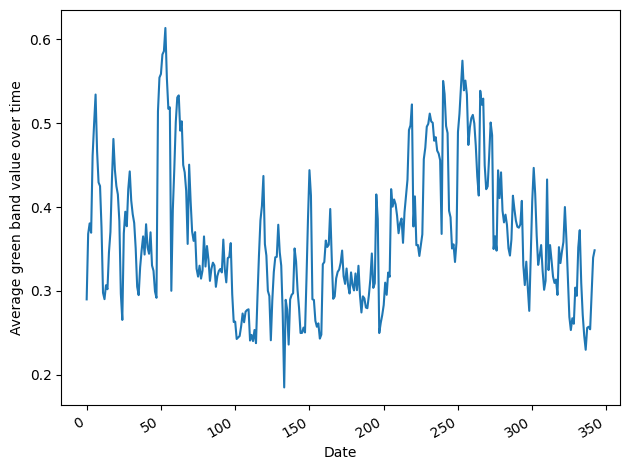

In [72]:
fig, ax = plt.subplots()

ax.plot(df_prophet['y'])
ax.set_xlabel('Date')
ax.set_ylabel('Average green band value over time')


fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [73]:
best_params = {'changepoint_prior_scale': 1.0, 'seasonality_prior_scale': 1.0}

In [74]:
m = Prophet(**best_params)
m.fit(train);

21:52:31 - cmdstanpy - INFO - Chain [1] start processing
21:52:32 - cmdstanpy - INFO - Chain [1] done processing


In [75]:
future = m.make_future_dataframe(periods=365, freq='D')

In [76]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
627,2024-11-19,0.780322,0.712991,0.849722
628,2024-11-20,0.783000,0.713221,0.844401
629,2024-11-21,0.780253,0.721801,0.850679
630,2024-11-22,0.771795,0.707499,0.837431
631,2024-11-23,0.757465,0.691264,0.821508
632,2024-11-24,0.737235,0.673189,0.800343
633,2024-11-25,0.711214,0.649770,0.776540
634,2024-11-26,0.679650,0.613709,0.743355
635,2024-11-27,0.642925,0.575443,0.707851
636,2024-11-28,0.601552,0.540663,0.667699


In [77]:
train

,y,ds
0,0.289978,2000-01-01
1,0.368054,2000-02-01
2,0.380592,2000-03-01
3,0.369503,2000-04-01
4,0.461369,2000-05-01
...,...,...
269,0.421405,2023-08-01
270,0.424756,2023-09-01
271,0.460975,2023-10-01
272,0.500949,2023-11-01


In [78]:
test[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']]
test

C:\Users\zizzi\AppData\Local\Temp\ipykernel_8836\81354400.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']]
C:\Users\zizzi\AppData\Local\Temp\ipykernel_8836\81354400.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']]
C:\Users\zizzi\AppData\Local\Temp\ipykernel_8836\81354400.py:1: SettingWithCopyWarning: 
A value is trying t

,y,ds,yhat,yhat_lower,yhat_upper
274,0.350012,2024-01-01,0.426956,0.365399,0.489731
275,0.365172,2024-02-01,0.374046,0.311520,0.433095
276,0.348134,2024-03-01,0.320785,0.258191,0.387024
277,0.443936,2024-04-01,0.268160,0.202343,0.329887
278,0.410795,2024-05-01,0.217161,0.154976,0.273004
...,...,...,...,...,...
338,0.257334,2029-08-01,0.635896,0.578665,0.698128
339,0.254293,2029-09-01,0.673459,0.610372,0.738083
340,0.296573,2029-10-01,0.707421,0.643925,0.768625
341,0.339782,2029-11-01,0.737125,0.677104,0.795781


In [79]:
test['Baseline'] = train['y'].iloc[-1]

C:\Users\zizzi\AppData\Local\Temp\ipykernel_8836\1212983594.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Baseline'] = train['y'].iloc[-1]


In [80]:
test

,y,ds,yhat,yhat_lower,yhat_upper,Baseline
274,0.350012,2024-01-01,0.426956,0.365399,0.489731,0.485796
275,0.365172,2024-02-01,0.374046,0.311520,0.433095,0.485796
276,0.348134,2024-03-01,0.320785,0.258191,0.387024,0.485796
277,0.443936,2024-04-01,0.268160,0.202343,0.329887,0.485796
278,0.410795,2024-05-01,0.217161,0.154976,0.273004,0.485796
...,...,...,...,...,...,...
338,0.257334,2029-08-01,0.635896,0.578665,0.698128,0.485796
339,0.254293,2029-09-01,0.673459,0.610372,0.738083,0.485796
340,0.296573,2029-10-01,0.707421,0.643925,0.768625,0.485796
341,0.339782,2029-11-01,0.737125,0.677104,0.795781,0.485796


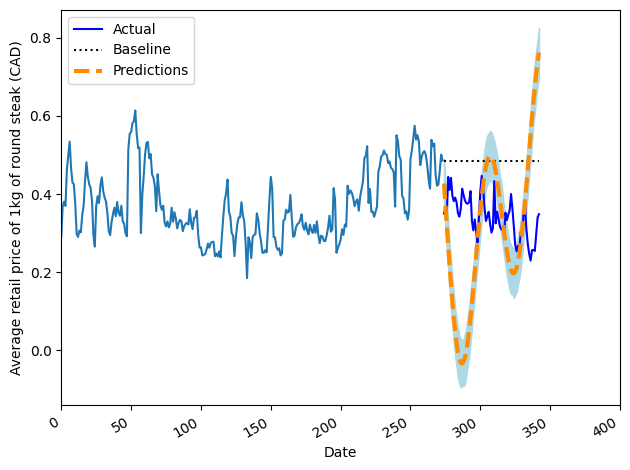

In [81]:
fig, ax = plt.subplots()

ax.plot(train['y'])
ax.plot(test['y'], 'b-', label='Actual')
ax.plot(test['Baseline'], 'k:', label='Baseline')
ax.plot(test['yhat'], color='darkorange', ls='--', lw=3, label='Predictions')

ax.set_xlabel('Date')
ax.set_ylabel('Average retail price of 1kg of round steak (CAD)')

#ax.axvspan(0, 24, color='#808080', alpha=0.1)

ax.legend(loc='best')

#plt.xticks(np.arange(0, 322, 12), np.arange(1995, 2022, 1))
plt.fill_between(x=test.index, y1=test['yhat_lower'], y2=test['yhat_upper'], color='lightblue')
plt.xlim(0, 400)
#plt.ylim(0.2, 0.7)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

### SARIMA

In [82]:
ad_fuller_result = adfuller(df_prophet['y'])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -1.9763778137706856
p-value: 0.29702567133133884


In [83]:
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [84]:
ps = range(1, 4, 1)
qs = range(1, 4, 1)
Ps = range(1, 4, 1)
Qs = range(1, 4, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 1
D = 0
s = 12

In [85]:
SARIMA_result_df = optimize_SARIMAX(train['y'], None, order_list, d, D, s)
SARIMA_result_df

C:\Users\zizzi\AppData\Local\Temp\ipykernel_8836\2780996986.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/81 [00:00<?, ?it/s]

C:\Users\zizzi\anaconda3\envs\geo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\zizzi\anaconda3\envs\geo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\zizzi\anaconda3\envs\geo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\zizzi\anaconda3\envs\geo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\zizzi\anaconda3\envs\geo\Lib\site-packages\statsmodels\

,"(p,q,P,Q)",AIC
0,"(1, 1, 1, 2)",-934.299714
1,"(1, 1, 2, 1)",-934.190854
2,"(1, 2, 1, 1)",-933.304413
3,"(1, 2, 1, 2)",-932.688874
4,"(1, 2, 2, 1)",-932.543105
...,...,...
76,"(3, 1, 3, 1)",-908.825561
77,"(2, 1, 3, 3)",-906.948084
78,"(3, 1, 3, 2)",-906.912894
79,"(3, 1, 2, 3)",-906.912024


In [86]:
p = 3
q = 3
P = 1
Q = 1

In [87]:
SARIMA_model = SARIMAX(train['y'], order=(p, d, q), seasonal_order=(P, D, Q, s), simple_differencing=False)
#SARIMA_model = SARIMAX(train['y'], order=(2,1,3), seasonal_order=(1,0,1,12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

C:\Users\zizzi\anaconda3\envs\geo\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\zizzi\anaconda3\envs\geo\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  274
Model:             SARIMAX(3, 1, 3)x(1, 0, [1], 12)   Log Likelihood                 474.317
Date:                              Wed, 10 Dec 2025   AIC                           -930.635
Time:                                      21:59:29   BIC                           -898.149
Sample:                                           0   HQIC                          -917.594
                                              - 274                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4678      0.270     -1.730      0.084      -0.998       0.062
ar.L2          0.32

C:\Users\zizzi\anaconda3\envs\geo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [88]:
residuals = SARIMA_model_fit.resid

lbvalue, pvalue = acorr_ljungbox(residuals, np.arange(1, 11, 1))

print(pvalue)

lb_pvalue


In [89]:
test

,y,ds,yhat,yhat_lower,yhat_upper,Baseline
274,0.350012,2024-01-01,0.426956,0.365399,0.489731,0.485796
275,0.365172,2024-02-01,0.374046,0.311520,0.433095,0.485796
276,0.348134,2024-03-01,0.320785,0.258191,0.387024,0.485796
277,0.443936,2024-04-01,0.268160,0.202343,0.329887,0.485796
278,0.410795,2024-05-01,0.217161,0.154976,0.273004,0.485796
...,...,...,...,...,...,...
338,0.257334,2029-08-01,0.635896,0.578665,0.698128,0.485796
339,0.254293,2029-09-01,0.673459,0.610372,0.738083,0.485796
340,0.296573,2029-10-01,0.707421,0.643925,0.768625,0.485796
341,0.339782,2029-11-01,0.737125,0.677104,0.795781,0.485796


In [90]:
SARIMA_pred = SARIMA_model_fit.get_prediction(274, 342).predicted_mean

test['SARIMA_pred'] = SARIMA_pred

C:\Users\zizzi\AppData\Local\Temp\ipykernel_8836\404951749.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['SARIMA_pred'] = SARIMA_pred


In [91]:
SARIMA_mae = mean_absolute_error(test['y'], test['SARIMA_pred'])

print(SARIMA_mae)

0.11924284514708394


In [92]:
test['y']
#s = pd.Series([1, 2, 3, np.nan, np.nan, None, pd.NA]) 

# Count the NA values
na_count = test['SARIMA_pred'].isna().sum() 

print(f"The number of NA values is: {na_count}") 

The number of NA values is: 0


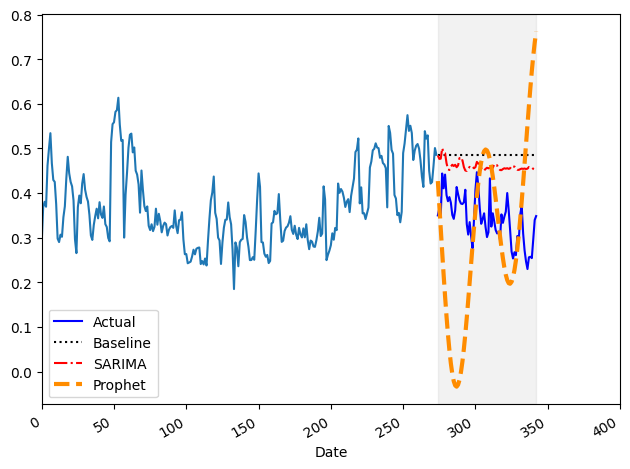

In [93]:
fig, ax = plt.subplots()

ax.plot(train['y'])
ax.plot(test['y'], 'b-', label='Actual')
ax.plot(test['Baseline'], 'k:', label='Baseline')
ax.plot(test['SARIMA_pred'], 'r-.', label='SARIMA')
ax.plot(test['yhat'], color='darkorange', ls='--', lw=3, label='Prophet')

ax.set_xlabel('Date')

ax.axvspan(274, 342, color='#808080', alpha=0.1)

ax.legend(loc='best')

#plt.xticks(np.arange(0, 322, 12), np.arange(1995, 2022, 1))
#plt.fill_between(x=test.index, y1=test['yhat_lower'], y2=test['yhat_upper'], color='lightblue')
plt.xlim(0, 400)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()